# Vizualizace
Tento notebook obsahuje podrobnou teorii k různým typům grafů v Pythonu, vysvětluje příkazy a jejich vstupy (inputs). Jako příklad používáme Titanic dataset (pasažéři, věk, pohlaví, třída, přežití).

... TEST POZNÁMKA PRO TEST VERZE NA GITU ...

# Spojité vs. Kategorické veličiny

V datové analýze se často setkáváme se dvěma základními typy dat:

---

## 1. Spojité veličiny
- **Definice:** Hodnoty, které představují **měření** a mohou nabývat libovolné číselné hodnoty (celé i desetinné).  
- Typicky vyjadřují **kvantitu** (kolik, jak velké, jak dlouhé).  

**Příklad:**
- Výška člověka (172,3 cm)  
- Váha psa (12,57 kg)  
- Čas běhu na 100 m (10,85 s)  

---

## 2. Kategorické veličiny
- **Definice:** Hodnoty, které představují **kategorie nebo skupiny**.  
- Není možné je smysluplně seřadit podle velikosti (u některých kategorií vůbec).  
- Typicky odpovídají **typům, skupinám nebo štítkům**.  

**Příklad:**
- Barva auta (červená, modrá, černá)  
- Pohlaví (muž, žena)  
- Země původu (Česko, Francie, USA)  

---

## Shrnutí v jedné větě
- **Spojité veličiny = čísla, která měříme.**  
- **Kategorické veličiny = názvy skupin, do kterých něco patří.**  

---

## Přehledná tabulka

| Typ veličiny        | Popis                                | Příklady                     |
|---------------------|--------------------------------------|------------------------------|
| **Spojitá**         | Čísla, která lze měřit               | výška, váha, čas, teplota    |
| **Kategorická**     | Skupiny, názvy, typy                 | barva auta, pohlaví, země    |


## 1. Import knihoven a dat
Používáme knihovny `matplotlib` pro základní grafy a `seaborn` pro statistické vizualizace.

```python
import matplotlib.pyplot as plt
import seaborn as sns
titanic = sns.load_dataset('titanic')
```

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
titanic = sns.load_dataset('titanic')

In [2]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## 2. Line plot (čárový graf)
- Spojitá x Spojitá
- Funkce: `plt.plot(x, y, ...)`
- Parametry (inputs):
  - `x` : seznam hodnot na ose x
  - `y` : seznam hodnot na ose y
  - `color` : barva čáry (např. 'blue')
  - `linestyle` : typ čáry ('-', '--', '-.', ':')
  - `marker` : tvar bodů ('o', 's', '^', atd.)
  - `label` : popisek legendy pro tuto čáru

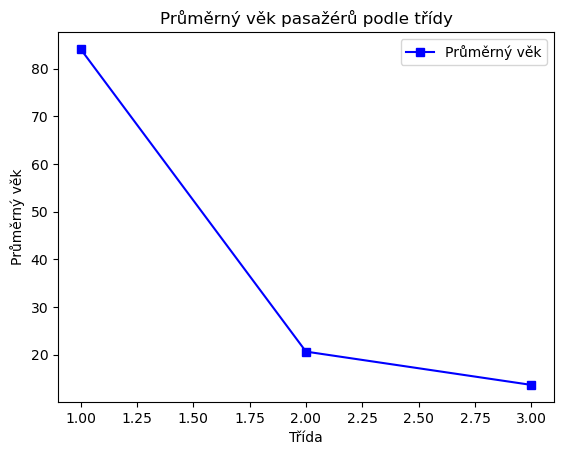

In [7]:
# Dataset na kterým chci graf zobrazovat
# ... viz Pandas, kdy dávám Groupby dle pclass, do sloupce Age kde chci průměr

mean_age_by_class = titanic.groupby('pclass')['fare'].mean()


# Definování grafu
plt.plot(mean_age_by_class.index, mean_age_by_class.values, color='blue', linestyle='-', marker='s', label='Průměrný věk')
plt.xlabel('Třída')
plt.ylabel('Průměrný věk')
plt.title('Průměrný věk pasažérů podle třídy')
plt.legend()

# Zobrazení grafu
plt.show()

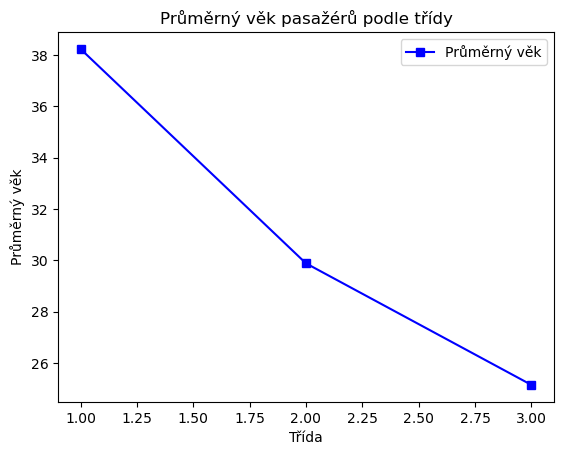

In [10]:
# Dataset na kterým chci graf zobrazovat
# ... viz Pandas, kdy dávám Groupby dle pclass, do sloupce Age kde chci průměr

mean_age_by_class = titanic.groupby('pclass')['age'].mean()


# Definování grafu
plt.plot(mean_age_by_class.index, mean_age_by_class.values, color='blue', linestyle='-', marker='s', label='Průměrný věk')
plt.xlabel('Třída')
plt.ylabel('Průměrný věk')
plt.title('Průměrný věk pasažérů podle třídy')
plt.legend()

# Zobrazení grafu
plt.show()

Text(0, 0.5, 'y')

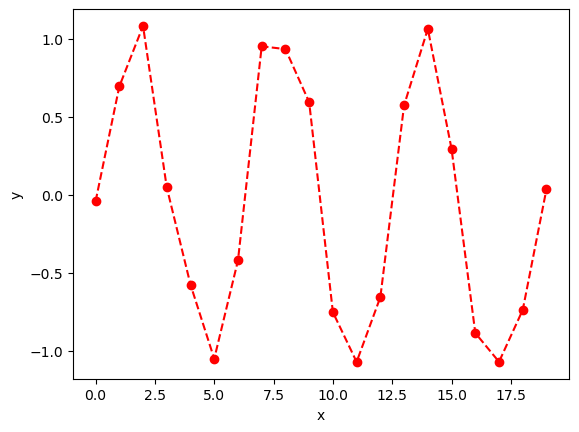

In [ ]:
import numpy as np
import pandas as pd

x = np.arange(0, 20, 1)
y = np.sin(x) + np.random.normal(0, 0.2, len(x))

df = pd.DataFrame({"x": x, "y": y})

plt.plot(df['x'], df['y'], color='red', linestyle='--', marker='o', label='Sinusoida')
plt.xlabel('x')
plt.ylabel('y')

# Korelace

## Co je korelace?
- **Korelace** měří **sílu a směr vztahu mezi dvěma číselnými (spojitými) veličinami**.  
- Říká nám, jestli když jedna veličina roste, druhá má tendenci růst nebo klesat.  

---

## Typy korelace
1. **Pozitivní korelace**  
   - Když jedna veličina roste, roste i druhá.  
   - Příklad: Výška a váha u lidí (většinou vyšší lidé váží více).  

2. **Negativní korelace**  
   - Když jedna veličina roste, druhá klesá.  
   - Příklad: Rychlost běžce a čas potřebný na uběhnutí 100 m (rychlejší běžec má kratší čas).  

3. **Žádná korelace**  
   - Mezi veličinami není žádný systematický vztah.  
   - Příklad: Barva auta a výška jeho majitele.  

---

## Korelační koeficient
- Číselně se vyjadřuje pomocí hodnoty mezi **-1 a 1**.  

| Hodnota korelace | Význam                            |
|------------------|-----------------------------------|
| **+1**           | dokonalá pozitivní korelace       |
| **0**            | žádná korelace                    |
| **-1**           | dokonalá negativní korelace       |

---

## Shrnutí v jedné větě
- **Korelace = ukazuje, jak silně spolu souvisí dvě číselné veličiny a zda jdou stejným nebo opačným směrem.**


## 3. Scatter plot (bodový graf)
- Funkce: `plt.scatter(x, y, ...)`
- Parametry:
  - `x` : hodnoty na ose x
  - `y` : hodnoty na ose y
  - `s` : velikost bodů
  - `c` : barva bodů
  - `marker` : tvar bodu
  - `alpha` : průhlednost bodu

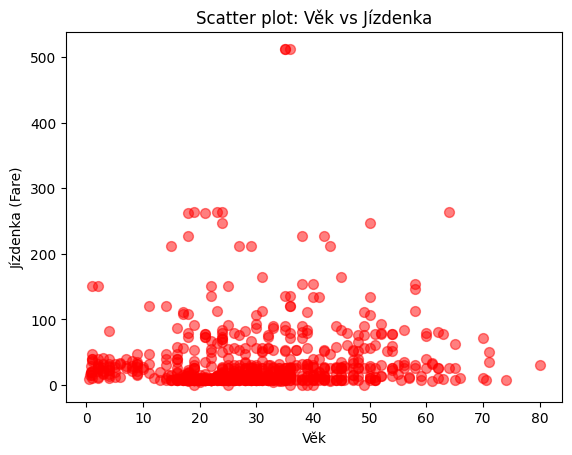

In [ ]:
plt.scatter(titanic['age'], titanic['fare'], s=50, c='red', alpha=0.5)
plt.xlabel('Věk')
plt.ylabel('Jízdenka (Fare)')
plt.title('Scatter plot: Věk vs Jízdenka')
plt.show()

In [15]:
n = 100
# Positively correlated
x_pos = np.linspace(0, 10, n)
y_pos = 2 * x_pos + np.random.normal(0, 2, n)

# Negatively correlated
x_neg = np.linspace(0, 10, n)
y_neg = -2 * x_neg + np.random.normal(0, 2, n)

# Not correlated
x_rand = np.linspace(0, 10, n)
y_rand = np.random.normal(0, 5, n)

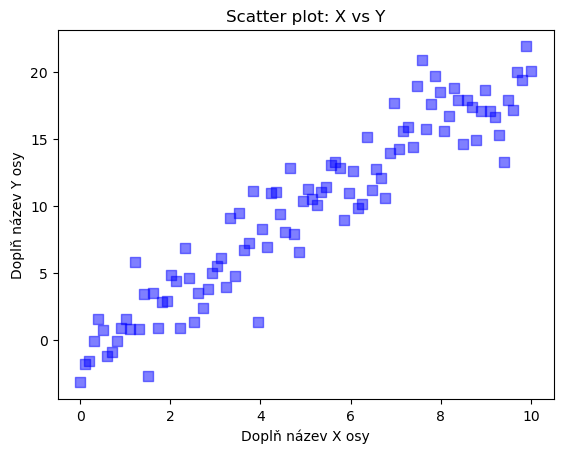

In [20]:
plt.scatter(x_pos, y_pos, s=50, c='blue', marker='s', alpha=0.5)
plt.xlabel('Doplň název X osy')
plt.ylabel('Doplň název Y osy')
plt.title('Scatter plot: X vs Y')
plt.show()

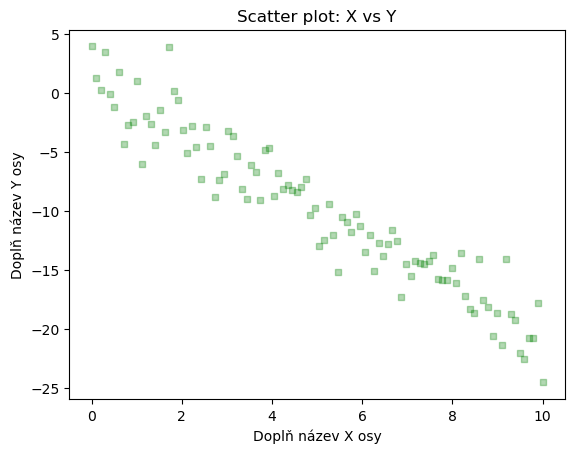

In [23]:
plt.scatter(x_neg, y_neg, s=20, c='green', marker='s', alpha=0.3)
plt.xlabel('Doplň název X osy')
plt.ylabel('Doplň název Y osy')
plt.title('Scatter plot: X vs Y')
plt.show()

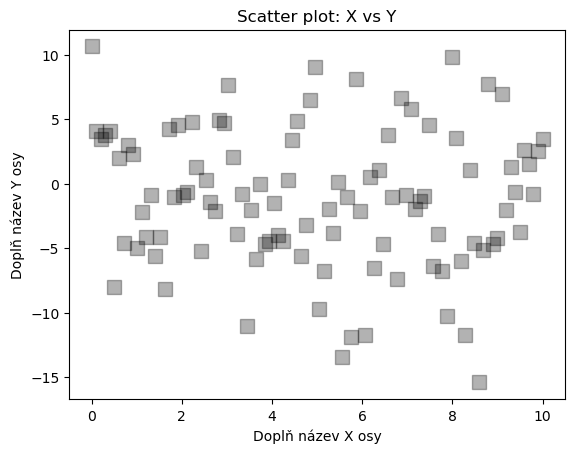

In [25]:
plt.scatter(x_rand, y_rand, s=100, c='black', marker='s', alpha=0.3)
plt.xlabel('Doplň název X osy')
plt.ylabel('Doplň název Y osy')
plt.title('Scatter plot: X vs Y')
plt.show()

## 5. Histogram
- Rozdělení spojité veličiny
- Funkce: `plt.hist(x, ...)`
- Parametry:
  - `x` : data
  - `bins` : počet intervalů
  - `range` : rozsah hodnot
  - `density` : True = normalizace
  - `color` : barva sloupců
  - `alpha` : průhlednost

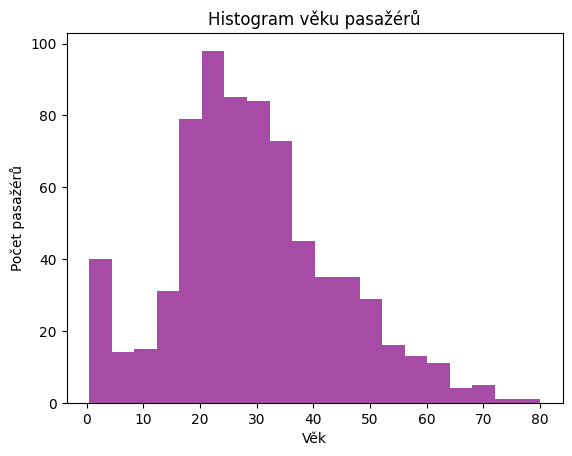

In [ ]:
plt.hist(titanic['age'].dropna(), bins=20, color='purple', alpha=0.7)

plt.xlabel('Věk')
plt.ylabel('Počet pasažérů')
plt.title('Histogram věku pasažérů')
plt.show()

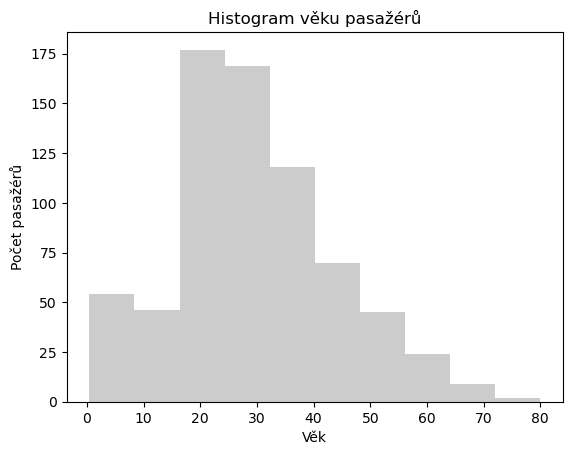

In [ ]:
plt.hist(titanic['age'].dropna(), bins=10, color='black', alpha=0.2)

plt.xlabel('Věk')
plt.ylabel('Počet pasažérů')
plt.title('Histogram věku pasažérů')
plt.show()

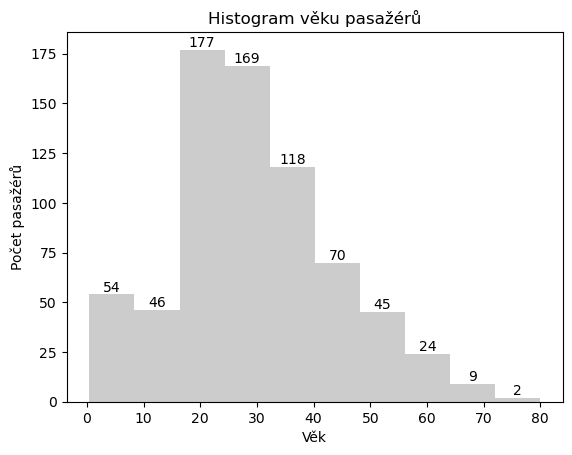

In [ ]:
plt.hist(titanic['age'].dropna(), bins=10, color='black', alpha=0.2)

plt.bar_label(plt.gca().containers[0])  # přidá počet "vhození" nad biny

plt.xlabel('Věk')
plt.ylabel('Počet pasažérů')
plt.title('Histogram věku pasažérů')
plt.show()


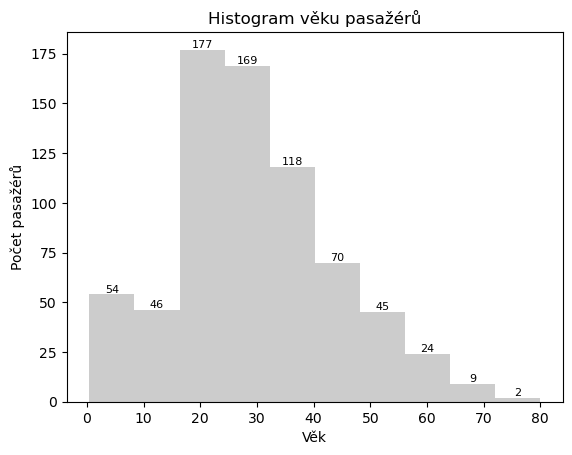

In [37]:
plt.hist(titanic['age'].dropna(), bins=10, color='black', alpha=0.2)

for c, p in zip(counts, patches):
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    plt.text(x, y, f"{int(c)}", ha='center', va='bottom', fontsize=8)

plt.xlabel('Věk')
plt.ylabel('Počet pasažérů')
plt.title('Histogram věku pasažérů')
plt.show()

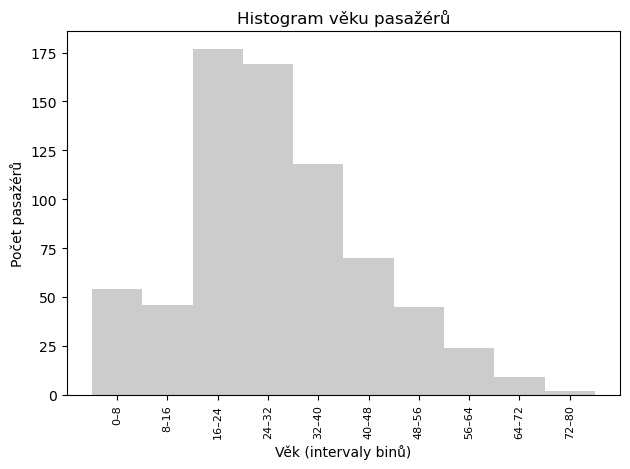

In [32]:
plt.hist(titanic['age'].dropna(), bins=10, color='black', alpha=0.2)

centers = (bins[:-1] + bins[1:]) / 2
labels = [f"{int(bins[i])}–{int(bins[i+1])}" for i in range(len(bins)-1)]
plt.xticks(centers, labels, rotation=90, fontsize=8)

# osa, titulek
plt.xlabel('Věk (intervaly binů)')
plt.ylabel('Počet pasažérů')
plt.title('Histogram věku pasažérů')

# trochu místa pro spodní popisky
plt.gcf().subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

## 4. Bar plot (sloupcový graf)
- Kategoriální x Spojitá
- Funkce: `plt.bar(x, height, ...)`
- Parametry:
  - `x` : kategorie na ose x
  - `height` : výška sloupců
  - `width` : šířka sloupců (default 0.8)
  - `color` : barva sloupců

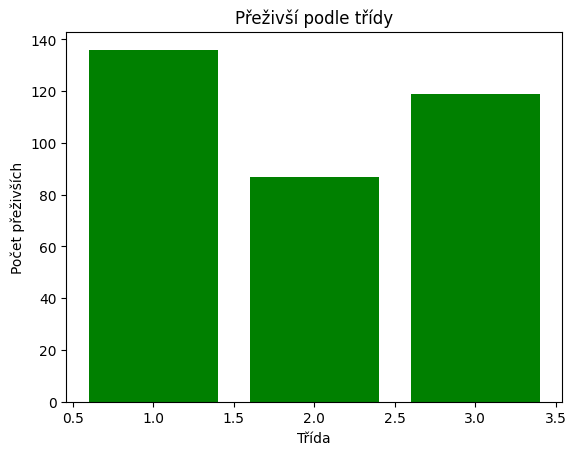

In [ ]:
survived_count_by_class = titanic.groupby('pclass')['survived'].sum()
plt.bar(survived_count_by_class.index, survived_count_by_class.values, color='green')
plt.xlabel('Třída')
plt.ylabel('Počet přeživších')
plt.title('Přeživší podle třídy')
plt.show()

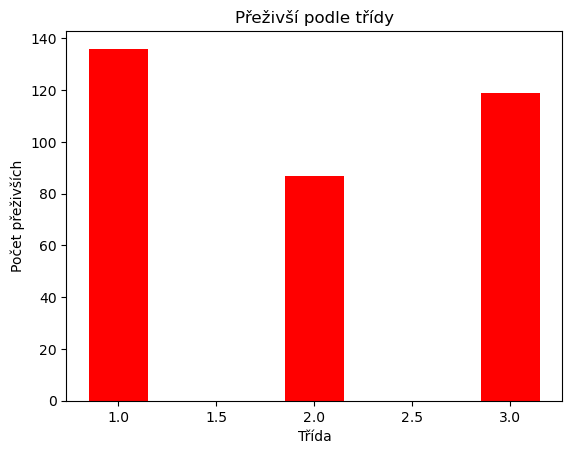

In [40]:
survived_count_by_class = titanic.groupby('pclass')['survived'].sum()

plt.bar(survived_count_by_class.index, survived_count_by_class.values, width=0.3, color='red')

plt.xlabel('Třída')
plt.ylabel('Počet přeživších')
plt.title('Přeživší podle třídy')
plt.show()

## 7. Box plot
- Funkce: `plt.boxplot(x, ...)`
- Parametry:
  - `x` : data (může být seznam seznamů)
  - `vert` : orientace (True = vertikálně)
  - `patch_artist` : vybarvení boxů
  - `labels` : popisky kategorií

In [41]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


/tmp/ipython-input-1275076089.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([titanic[titanic['pclass']==1]['age'].dropna(),


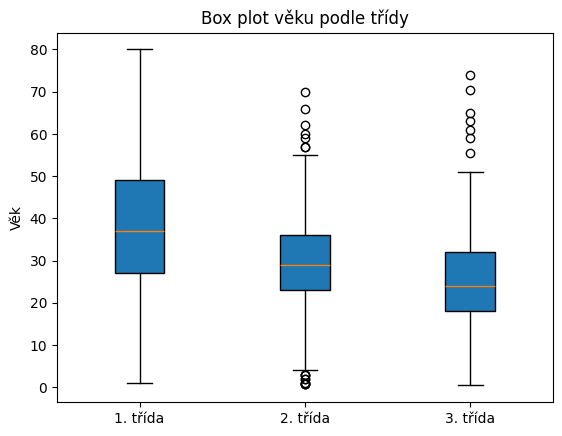

In [ ]:
plt.boxplot([titanic[titanic['pclass']==1]['age'].dropna(),
             titanic[titanic['pclass']==2]['age'].dropna(),
             titanic[titanic['pclass']==3]['age'].dropna()],
            labels=['1. třída', '2. třída', '3. třída'], patch_artist=True)
plt.ylabel('Věk')
plt.title('Box plot věku podle třídy')
plt.show()

In [42]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\745994598.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([titanic[titanic['survived']==0]['age'].dropna(),


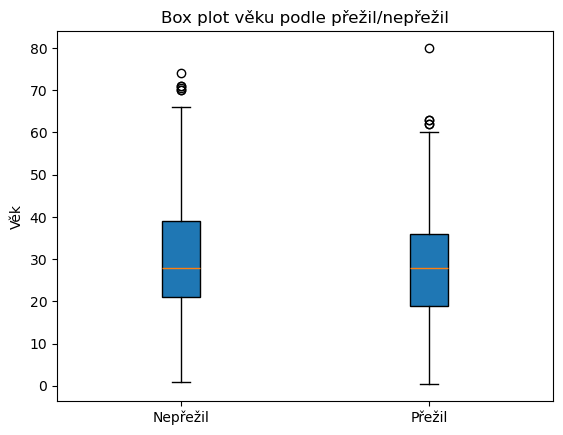

In [50]:
plt.boxplot([titanic[titanic['survived']==0]['age'].dropna(),
             titanic[titanic['survived']==1]['age'].dropna()],
             labels=['Nepřežil', 'Přežil'], patch_artist=True)
plt.ylabel('Věk')
plt.title('Box plot věku podle přežil/nepřežil')
plt.show()

## 8. Pie chart
- Funkce: `plt.pie(x, ...)`
- Parametry:
  - `x` : hodnoty
  - `labels` : popisky
  - `colors` : barvy segmentů
  - `autopct` : zobrazení procent
  - `startangle` : úhel rotace
  - `explode` : oddělení segmentů

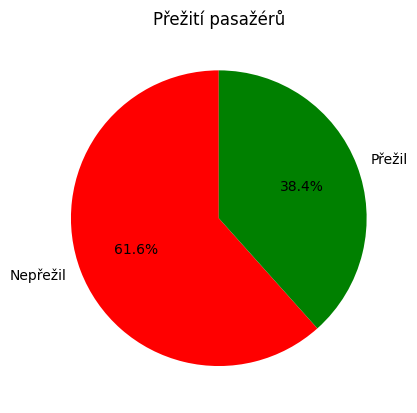

In [ ]:
survived_counts = titanic['survived'].value_counts()
plt.pie(survived_counts, labels=['Nepřežil','Přežil'], autopct='%1.1f%%', colors=['red','green'], startangle=90)
plt.title('Přežití pasažérů')
plt.show()

In [46]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


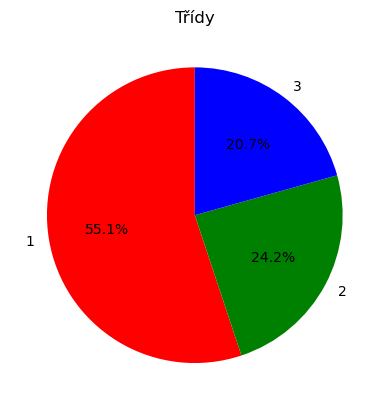

In [49]:
survived_counts = titanic['pclass'].value_counts()
plt.pie(survived_counts, labels=['1','2', '3'], autopct='%1.1f%%', colors=['red','green','blue'], startangle=90)
plt.title('Třídy')
plt.show()

## 11. Heatmap
- Funkce: `sns.heatmap(data, ...)`
- Parametry:
  - `data` : matice hodnot
  - `annot` : zobrazit čísla
  - `fmt` : formát čísla
  - `cmap` : barevná mapa
  - `linewidths` : čáry mezi buňkami

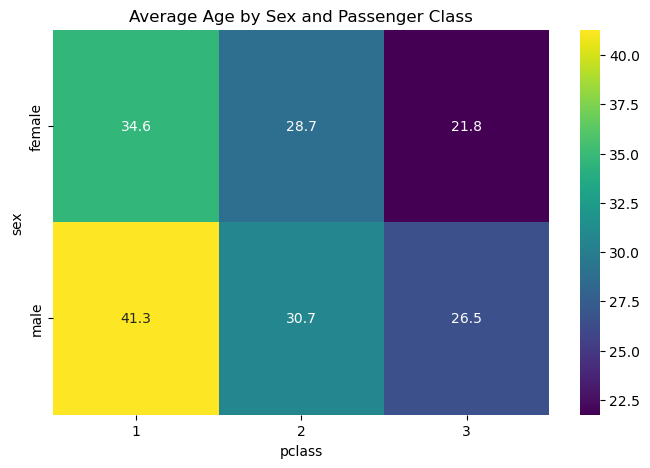

In [55]:
pivot = titanic.pivot_table(values="age", index="sex", columns="pclass", aggfunc="mean")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".1f")

plt.title("Average Age by Sex and Passenger Class")
plt.show()

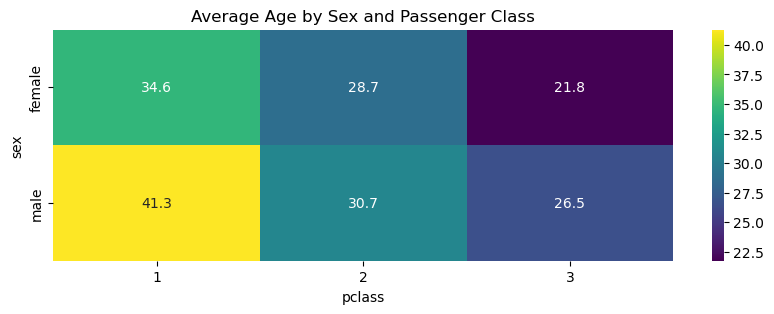

In [58]:
pivot = titanic.pivot_table(values="age", index="sex", columns="pclass", aggfunc="mean")

plt.figure(figsize=(10, 3))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".1f")

plt.title("Average Age by Sex and Passenger Class")
plt.show()


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [105]:
import seaborn as sns

flights = sns.load_dataset("flights")

import pandas as pd



In [71]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Dataset: Flights

### Sloupce
- `year` – rok (např. 1949, 1950 …)  
- `month` – měsíc (January, February …)  
- `passengers` – počet cestujících  

---

### Možné otázky pro datovou analýzu

#### 1. Základní popisná statistika
1. Kolik celkem letových záznamů dataset obsahuje?  
2. Jaký je průměrný, min a max počet cestujících?  
3. Jaký je celkový počet cestujících za každý rok?  

#### 2. Analýza podle měsíců
4. Který měsíc má historicky nejvíce cestujících?  
5. Který měsíc má nejméně cestujících?  
6. Jak se liší průměrný počet cestujících mezi zimními a letními měsíci?  

#### 3. Trendy v čase
7. Jak se měnil počet cestujících rok od roku? (line plot)  
8. Existuje sezónní trend v počtu cestujících v jednotlivých měsících? (heatmap nebo line plot)  
9. Který rok měl největší nárůst počtu cestujících oproti předchozímu roku?  

#### 4. Vizualizace
10. Vytvoř heatmapu počtu cestujících podle měsíce a roku.  
11. Vytvoř line plot pro každý měsíc, aby se ukázal trend v čase.  

#### 5. Pokročilé otázky
12. Který měsíc je nejstabilnější (nejmenší variabilita v počtu cestujících)?  
13. Existuje korelace mezi měsíčními a ročními trendy?


#### 1. Základní popisná statistika
1. Kolik celkem letových záznamů dataset obsahuje?  
2. Jaký je průměrný, min a max počet cestujících?  
3. Jaký je celkový počet cestujících za každý rok?  

In [ ]:
# 1.1) počet řádků = počet záznamů

print("Počet záznamů:", len(flights))

Počet záznamů: 144


In [ ]:
# 1.2) Průměrný, min a max počet cestujících

print("Průměrný počet cestujících:", flights['passengers'].mean())
print("Minimální počet cestujících:", flights['passengers'].min())
print("Maximální počet cestujících:", flights['passengers'].max())



Průměrný počet cestujících: 280.2986111111111
Minimální počet cestujících: 104
Maximální počet cestujících: 622


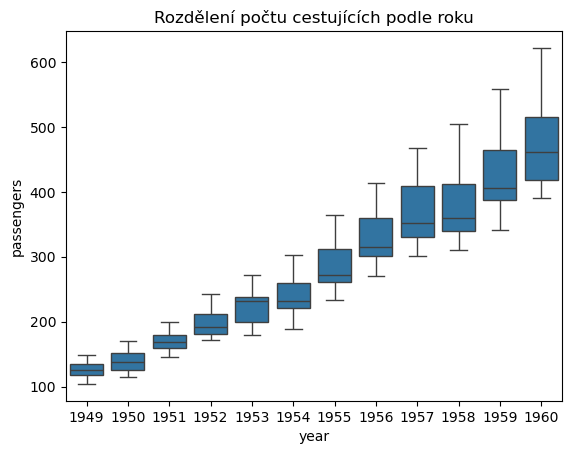

In [79]:
# 1.2) Boxplot (rozložení cestujících podle roku)

sns.boxplot(data=flights, x="year", y="passengers")
plt.title("Rozdělení počtu cestujících podle roku")
plt.show()

In [86]:
# 1.3) Celkový počet cestujících za každý rok

passengers_by_year = flights.groupby('year')['passengers'].sum()
print(passengers_by_year)



year
1949    1520
1950    1676
1951    2042
1952    2364
1953    2700
1954    2867
1955    3408
1956    3939
1957    4421
1958    4572
1959    5140
1960    5714
Name: passengers, dtype: int64


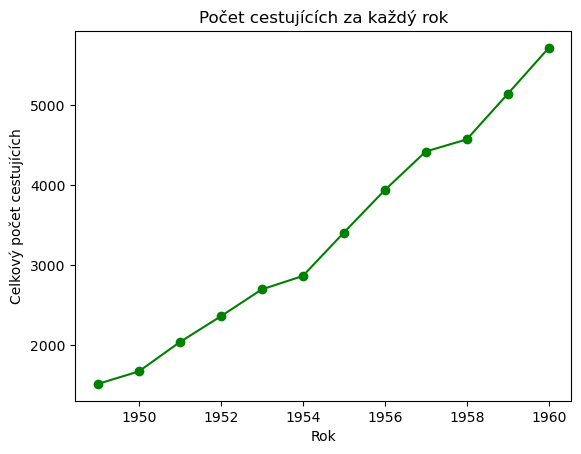

In [87]:
# 1.3) Line plot (celkový počet cestujících za každý rok)

passengers_by_year.plot(kind="line", marker="o", color="green")
plt.xlabel("Rok")
plt.ylabel("Celkový počet cestujících")
plt.title("Počet cestujících za každý rok")
plt.show()

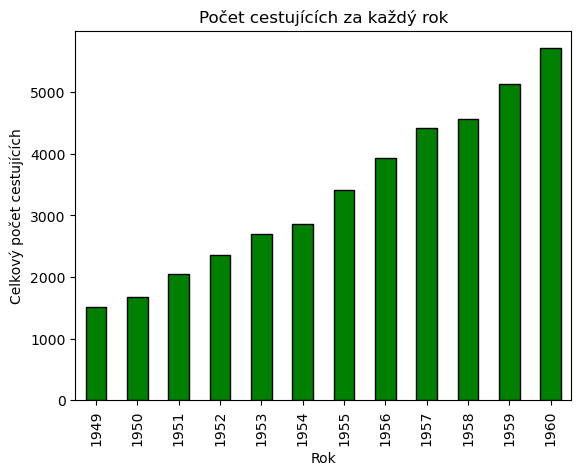

In [118]:
passengers_by_year.plot(kind="bar", color="green", edgecolor="black")

plt.xlabel("Rok")
plt.ylabel("Celkový počet cestujících")
plt.title("Počet cestujících za každý rok")
plt.show()

#### 2. Analýza podle měsíců
4. Který měsíc má historicky nejvíce cestujících?  
5. Který měsíc má nejméně cestujících?  
6. Jak se liší průměrný počet cestujících mezi zimními a letními měsíci?  

In [120]:
# 2.4) Který měsíc má historicky nejvíce cestujících?
# 2.5) Který měsíc má nejméně cestujících?


# průměrný počet cestujících podle měsíce (přes všechny roky)

print("Měsíc s nejméně cestujícími:", mean_by_month.index[0], round(mean_by_month.iloc[0], 1))
print("Měsíc s nejvíce cestujícími:", mean_by_month.index[-1], round(mean_by_month.iloc[-1], 1))

# najdeme řádek s max a min počtem cestujících

min_row = flights.loc[flights["passengers"].idxmin()]
max_row = flights.loc[flights["passengers"].idxmax()]

print("Nejméně cestujících:", min_row["passengers"], "→", min_row["month"], min_row["year"])
print("Nejvíce cestujících:", max_row["passengers"], "→", max_row["month"], max_row["year"])


Měsíc s nejméně cestujícími: Nov 232.8
Měsíc s nejvíce cestujícími: Jul 351.3
Nejméně cestujících: 104 → Nov 1949
Nejvíce cestujících: 622 → Jul 1960


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\1069476075.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_month = flights.groupby("month")["passengers"].mean().sort_values()


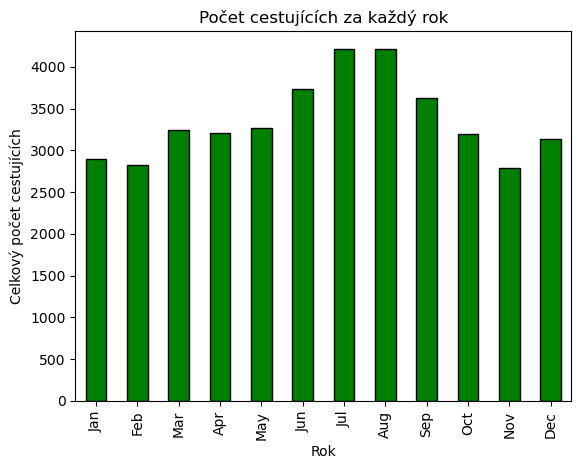

In [ ]:
mean_by_month = flights.groupby("month")["passengers"].mean().sort_values()

passengers_by_month.plot(kind="bar", color="green", edgecolor="black")

plt.xlabel("Měsíc")
plt.ylabel("Celkový počet cestujících")
plt.title("Počet cestujících za každý měsíc")
plt.show()

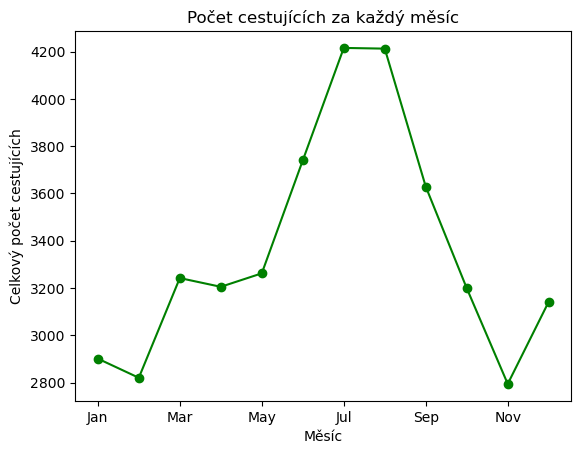

In [102]:
# 2.4) Line plot (celkový počet cestujících za každý měsíc)

passengers_by_month_sum.plot(kind="line", marker="o", color="green")
plt.xlabel("Měsíc")
plt.ylabel("Celkový počet cestujících")
plt.title("Počet cestujících za každý měsíc")
plt.show()

In [117]:
# 2.6) Jak se liší průměrný počet cestujících mezi zimními a letními měsíci?

flights = sns.load_dataset("flights")

# Rozdělení měsíců do sezón
winter = ["Dec", "Jan", "Feb"]
summer = ["Jun", "Jul", "Aug"]

# Průměrné hodnoty
mean_winter = flights[flights["month"].isin(winter)]["passengers"].mean()
mean_summer = flights[flights["month"].isin(summer)]["passengers"].mean()

print("Průměrný počet cestujících (zima):", round(mean_winter, 2))
print("Průměrný počet cestujících (léto):", round(mean_summer, 2))

Průměrný počet cestujících (zima): 246.19
Průměrný počet cestujících (léto): 338.03


In [ ]:
def get_season(month):
  if month in ["Jan","Dec","Feb"]:
    return "zima"
  elif month in ("Jun","Jul","Aug"):
    return "leto"
  else:
    return "ostatni"
  
df["season"] = df["month"].apply(get_season)
sezoni_cestujici = df.groupby("season")["passengers"].mean()

plt.bar(sezoni_cestujici.index, sezoni_cestujici.values, color='green')
plt.xlabel('rocni obdobi')
plt.ylabel('pocet cestujich(avg)')
plt.title('Prumerny pocet cestujich podle rocniho obdobi')
plt.show()

KeyError: 'month'

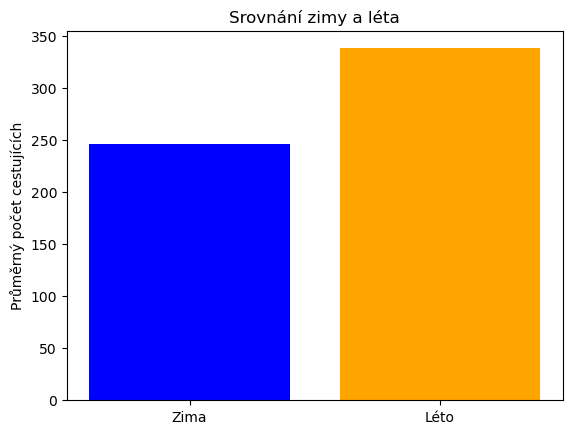

In [107]:
import matplotlib.pyplot as plt

seasons = ["Zima", "Léto"]
values = [mean_winter, mean_summer]

plt.bar(seasons, values, color=["blue", "orange"])
plt.ylabel("Průměrný počet cestujících")
plt.title("Srovnání zimy a léta")
plt.show()

C:\Users\josef\AppData\Local\Temp\ipykernel_61236\2216488962.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights[flights["season"].isin(["Zima", "Léto"])],


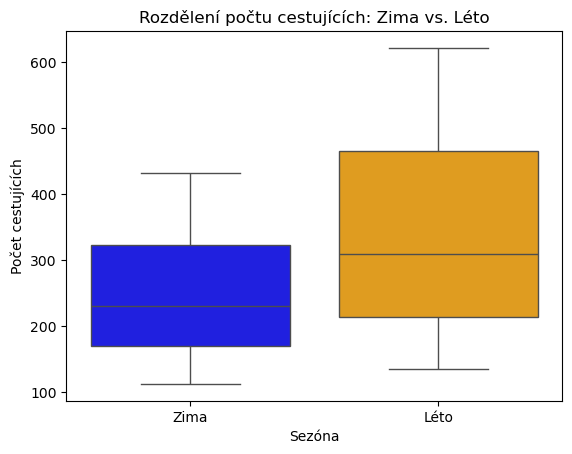

In [108]:
flights = sns.load_dataset("flights")

# Definice zimních a letních měsíců
winter = ["Dec", "Jan", "Feb"]
summer = ["Jun", "Jul", "Aug"]

# Přidáme nový sloupec se sezónou
def season(month):
    if month in winter:
        return "Zima"
    elif month in summer:
        return "Léto"
    else:
        return "Jiné"

flights["season"] = flights["month"].apply(season)

# Vykreslení boxplotu jen pro Zimu a Léto
sns.boxplot(data=flights[flights["season"].isin(["Zima", "Léto"])],
            x="season", y="passengers", palette={"Zima": "blue", "Léto": "orange"})

plt.title("Rozdělení počtu cestujících: Zima vs. Léto")
plt.xlabel("Sezóna")
plt.ylabel("Počet cestujících")
plt.show()

#### 3. Trendy v čase

7. Jak se měnil počet cestujících rok od roku? (line plot)  
8. Existuje sezónní trend v počtu cestujících v jednotlivých měsících? (heatmap nebo line plot)  
9. Který rok měl největší nárůst počtu cestujících oproti předchozímu roku? 

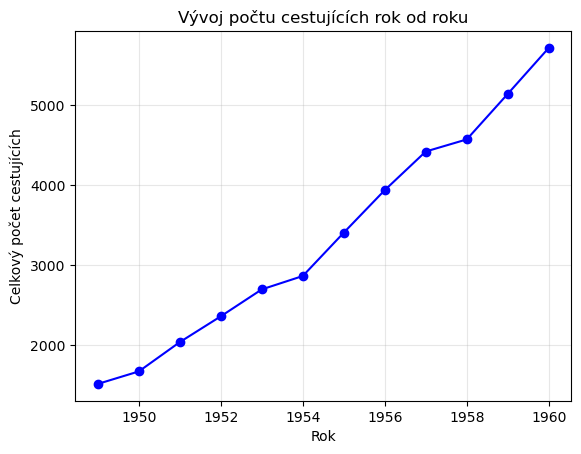

In [123]:
# 7. Jak se měnil počet cestujících rok od roku? (line plot)  

# Součet cestujících za každý rok
passengers_by_year = flights.groupby("year")["passengers"].sum()

plt.plot(passengers_by_year.index, passengers_by_year.values,
         marker="o", color="blue")
plt.xlabel("Rok")
plt.ylabel("Celkový počet cestujících")
plt.title("Vývoj počtu cestujících rok od roku")
plt.grid(True, alpha=0.3)
plt.show()

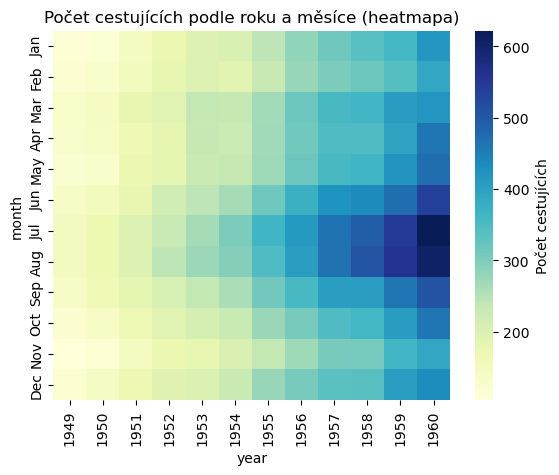

In [104]:
# 8. Existuje sezónní trend v počtu cestujících v jednotlivých měsících? (heatmap nebo line plot)  

flights_pivot = flights.pivot(index="month", columns="year", values="passengers")

sns.heatmap(flights_pivot, cmap="YlGnBu", annot=False, cbar_kws={'label': 'Počet cestujících'})
plt.title("Počet cestujících podle roku a měsíce (heatmapa)")
plt.show()

C:\Users\josef\AppData\Local\Temp\ipykernel_61236\1275128750.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(flights, values='passengers', index='year', columns='month', aggfunc='sum')


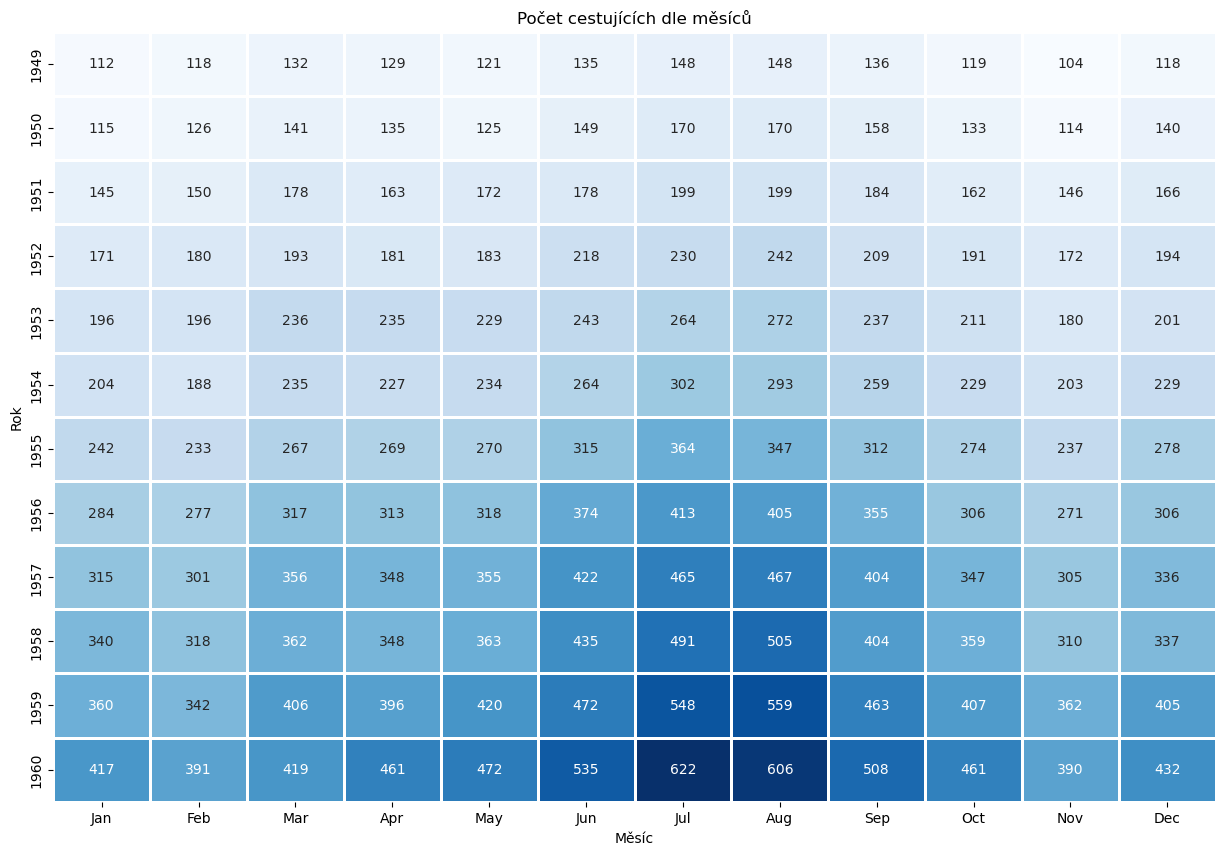

In [124]:
pivot = pd.pivot_table(flights, values='passengers', index='year', columns='month', aggfunc='sum')
plt.figure(figsize=(15, 10))
sns.heatmap(pivot, annot=True, cmap='Blues', cbar=False, linewidths=True, fmt='.0f')
plt.xlabel('Měsíc')
plt.ylabel('Rok')
plt.title('Počet cestujících dle měsíců')
plt.show()

In [126]:
# 9. Který rok měl největší nárůst počtu cestujících oproti předchozímu roku? 

p_per_y = flights.groupby("year")["passengers"].sum()

predchozi = 0
max_roz = 0
max_year = 0

for year, total in p_per_y.items():
    if predchozi != 0:
        diff = total - predchozi
        if diff > max_roz:
            max_roz = diff
            max_year = year
    predchozi = total

print(f"Nejvetsi narust byl v roce {max_year} o {max_roz} lidi.")

Nejvetsi narust byl v roce 1960 o 574 lidi.


In [ ]:
# 9. Který rok měl největší nárůst počtu cestujících oproti předchozímu roku? 

flights = sns.load_dataset("flights")

# Součet cestujících za rok
passengers_by_year = flights.groupby("year")["passengers"].sum()

# Meziroční rozdíl
diffs = passengers_by_year.diff()

# Najdeme rok s největším nárůstem
max_increase_year = diffs.idxmax()
max_increase_value = diffs.max()

print("Největší nárůst:", int(max_increase_value), "cestujících oproti předchozímu roku,", 
      "rok:", max_increase_year)


Největší nárůst: 574 cestujících oproti předchozímu roku, rok: 1960


In [132]:
# 9. Který rok měl největší nárůst počtu cestujících oproti předchozímu roku? 

import seaborn as sns
import pandas as pd

# načtení datasetu
flights = sns.load_dataset("flights")

# součet cestujících za každý rok
passengers_by_year = flights.groupby("year")["passengers"].sum()

# diferenciál (meziroční změna)
diffs = passengers_by_year.diff()

# tabulka
diff_table = pd.DataFrame({
    "Počet cestujících": passengers_by_year,
    "Meziroční změna": diffs
})

print(diff_table)


      Počet cestujících  Meziroční změna
year                                    
1949               1520              NaN
1950               1676            156.0
1951               2042            366.0
1952               2364            322.0
1953               2700            336.0
1954               2867            167.0
1955               3408            541.0
1956               3939            531.0
1957               4421            482.0
1958               4572            151.0
1959               5140            568.0
1960               5714            574.0


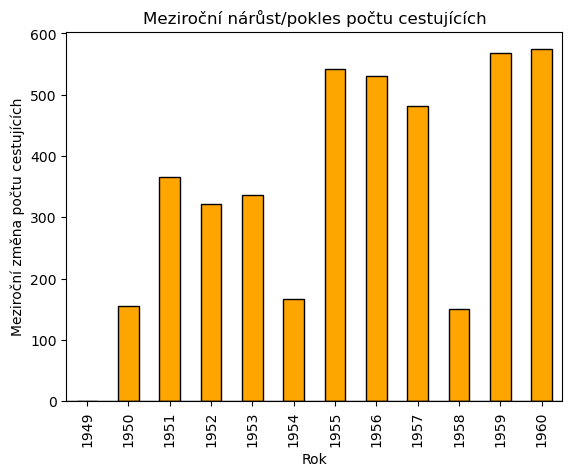

In [131]:
# 9. Který rok měl největší nárůst počtu cestujících oproti předchozímu roku? 

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# dataset flights
flights = sns.load_dataset("flights")

# součet cestujících za každý rok
passengers_by_year = flights.groupby("year")["passengers"].sum()

# meziroční změna
diffs = passengers_by_year.diff()

# sloupcový graf diferenciálu
diffs.plot(kind="bar", color="orange", edgecolor="black")

plt.axhline(0, color="black", linewidth=1)   # čára pro nulu
plt.xlabel("Rok")
plt.ylabel("Meziroční změna počtu cestujících")
plt.title("Meziroční nárůst/pokles počtu cestujících")
plt.show()


#### 4. Vizualizace
10. Vytvoř heatmapu počtu cestujících podle měsíce a roku.  
11. Vytvoř line plot pro každý měsíc, aby se ukázal trend v čase.

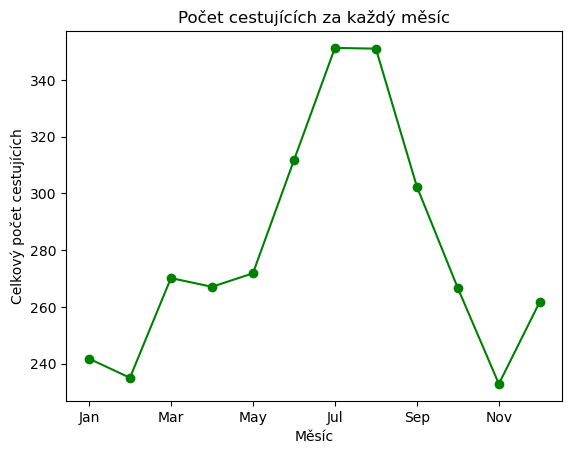

In [116]:
# 4.11) Line plot (průměr cestujících za každý měsíc)

passengers_by_month_mean.plot(kind="line", marker="o", color="green")
plt.xlabel("Měsíc")
plt.ylabel("Celkový počet cestujících")
plt.title("Počet cestujících za každý měsíc")
plt.show()

In [61]:
import seaborn as sns

df_tips = sns.load_dataset("tips")

In [ ]:
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


# Dataset: Tips (spropitné v restauraci)

Tento dataset pochází z americké restaurace a obsahuje údaje o účtech a spropitném.  
Často se používá pro výuku datové analýzy a vizualizace.  

---

## Sloupce v datasetu

- **total_bill**  
  Celková částka účtu (v dolarech).  

- **tip**  
  Výše spropitného (v dolarech).  

- **sex**  
  Pohlaví osoby, která platila účet.  
  - `Male` = muž  
  - `Female` = žena  

- **smoker**  
  Zda byla osoba kuřák nebo ne.  
  - `Yes` = kuřák  
  - `No` = nekuřák  

- **day**  
  Den v týdnu, kdy byla návštěva v restauraci.  
  - `Thur` = čtvrtek  
  - `Fri` = pátek  
  - `Sat` = sobota  
  - `Sun` = neděle  

- **time**  
  Čas návštěvy.  
  - `Lunch` = oběd  
  - `Dinner` = večeře  

- **size**  
  Počet osob u stolu (velikost skupiny).  

---

# Otázky pro datovou analýzu (dataset Tips), použijte vizualizaci u všech otázek, kde to jde.

## 1. Základní popisné otázky
1. Jaký je průměrný účet (`total_bill`) a průměrné spropitné (`tip`)?  
2. Jaká je mediánová velikost skupiny (`size`) v restauraci?  
3. Jaký je podíl mužů a žen (`sex`) mezi platícími?  
4. Kolik procent zákazníků byli kuřáci (`smoker`)?  

---

## 2. Porovnávání mezi skupinami
5. Dávají muži a ženy odlišné spropitné (v absolutní částce i v % účtu)?  
6. Mají kuřáci tendenci nechávat jiné spropitné než nekuřáci?  
7. Jak se liší účty a spropitné mezi obědem (`Lunch`) a večeří (`Dinner`)?  
8. Který den v týdnu má nejvyšší průměrný účet?  
9. Kdo dává relativně vyšší spropitné – muži nebo ženy – v poměru k účtu?  
10. Jaký je průměrný účet a spropitné pro kuřáky vs. nekuřáky rozdělené podle pohlaví?  

---

## 3. Vztahy mezi veličinami
11. Existuje korelace mezi výší účtu (`total_bill`) a výší spropitného (`tip`)?  
12. Zvyšuje se spropitné (v dolarech i %) s počtem osob u stolu (`size`)?  
13. Je procento spropitného vyšší u menších nebo větších účtů?  
14. Existuje vztah mezi velikostí skupiny (`size`) a procentem spropitného?  
15. Je korelace mezi účtem a spropitným silnější pro oběd nebo večeři?  
16. Jak se mění variabilita spropitného s počtem osob u stolu?  

---

## 4. Časové a denní trendy
17. Existuje rozdíl v spropitném mezi obědem a večeří pro každý den zvlášť?  
18. Který den v týdnu má nejvyšší průměrné procento spropitného (tip / total_bill)?  
19. Dá se odhadnout, zda lidé chodí častěji v určité dny nebo časy?  

## 1. Základní popisné otázky

1. Jaký je průměrný účet (`total_bill`) a průměrné spropitné (`tip`)?  
2. Jaká je mediánová velikost skupiny (`size`) v restauraci?  
3. Jaký je podíl mužů a žen (`sex`) mezi platícími?  
4. Kolik procent zákazníků byli kuřáci (`smoker`)?  

In [134]:
df_tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [133]:
# 1. Jaký je průměrný účet (`total_bill`) a průměrné spropitné (`tip`)?

mean_total_bill = df_tips["total_bill"].mean()
mean_tip = df_tips["tip"].mean()

print("Průměrný účet (total_bill):", round(mean_total_bill, 2))
print("Průměrné spropitné (tip):", round(mean_tip, 2))

Průměrný účet (total_bill): 19.79
Průměrné spropitné (tip): 3.0


In [137]:
# 2. Jaká je mediánová velikost skupiny (`size`) v restauraci?

median_size = df_tips["size"].median()

print("Mediánová velikost skupiny:", median_size)

Mediánová velikost skupiny: 2.0


In [143]:
# 3. Jaký je počet  mužů a žen (`sex`) mezi platícími? 

sex_counts = df_tips["sex"].value_counts()

print(sex_counts)

sex
Male      157
Female     87
Name: count, dtype: int64


In [138]:
# 3. Jaký je podíl mužů a žen (`sex`) mezi platícími? 

sex_counts = df_tips["sex"].value_counts()
sex_ratio = df_tips["sex"].value_counts(normalize=True) * 100

print("Počty:\n", sex_counts)
print("\nPodíly (%):\n", sex_ratio.round(2))

Počty:
 sex
Male      157
Female     87
Name: count, dtype: int64

Podíly (%):
 sex
Male      64.34
Female    35.66
Name: proportion, dtype: float64


In [ ]:
# 3. Jaký je podíl mužů a žen (`sex`) mezi platícími? 

import seaborn as sns
import pandas as pd
df_tips = sns.load_dataset("tips")

# počet
counts = df_tips["sex"].value_counts()

# podíl
ratios = df_tips["sex"].value_counts(normalize=True) * 100

# spojíme do tabulky
sex_table = pd.DataFrame({
    "Počet": counts,
    "Podíl (%)": ratios.round(2)
})

print(sex_table)


        Počet  Podíl (%)
sex                     
Male      157      64.34
Female     87      35.66


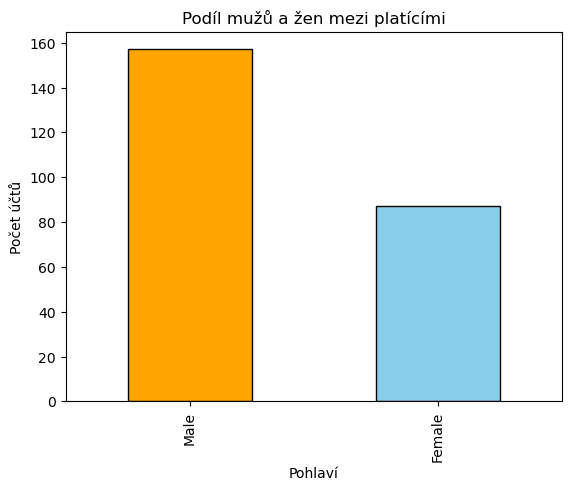

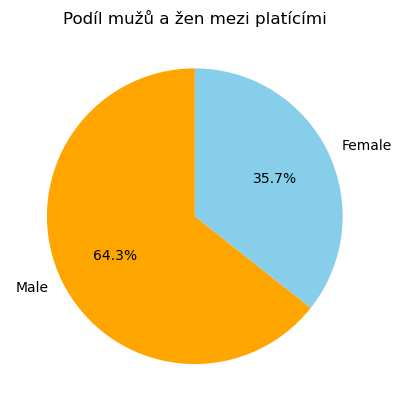

In [146]:
# 3. Jaký je podíl mužů a žen (`sex`) mezi platícími? 

sex_counts = df_tips["sex"].value_counts()

# sloupcový graf
sex_counts.plot(kind="bar", color=["orange", "skyblue"], edgecolor="black")
plt.xlabel("Pohlaví")
plt.ylabel("Počet účtů")
plt.title("Podíl mužů a žen mezi platícími")
plt.show()


# koláčový graf
sex_counts.plot(
    kind="pie",
    autopct="%.1f%%",          # procenta s jedním desetinným místem
    colors=["orange", "skyblue"],
    startangle=90,
    ylabel=""                  # odstraní popisek osy
)

plt.title("Podíl mužů a žen mezi platícími")
plt.show()

In [147]:
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


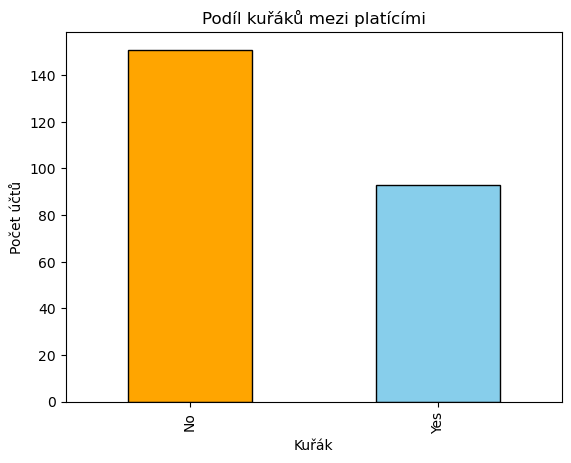

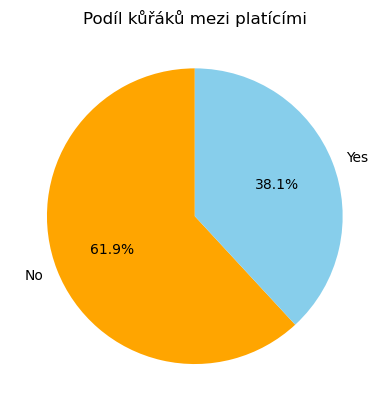

In [152]:
# 4. Kolik procent zákazníků byli kuřáci (`smoker`)?

smoker_counts = df_tips["smoker"].value_counts()

# sloupcový graf
smoker_counts.plot(kind="bar", color=["orange", "skyblue"], edgecolor="black")
plt.xlabel("Kuřák")
plt.ylabel("Počet účtů")

plt.title("Podíl kuřáků mezi platícími")
plt.show()


# koláčový graf
smoker_counts.plot(
    kind="pie",
    autopct="%.1f%%",          # procenta s jedním desetinným místem
    colors=["orange", "skyblue"],
    startangle=90,
    ylabel=""                  # odstraní popisek osy
)

plt.title("Podíl kůřáků mezi platícími")
plt.show()


## 2. Porovnávání mezi skupinami
5. Dávají muži a ženy odlišné spropitné (v absolutní částce i v % účtu)?  
6. Mají kuřáci tendenci nechávat jiné spropitné než nekuřáci?  
7. Jak se liší účty a spropitné mezi obědem (`Lunch`) a večeří (`Dinner`)?  
8. Který den v týdnu má nejvyšší průměrný účet?  
9. Kdo dává relativně vyšší spropitné – muži nebo ženy – v poměru k účtu?  
10. Jaký je průměrný účet a spropitné pro kuřáky vs. nekuřáky rozdělené podle pohlaví?

In [155]:
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


In [ ]:
# 5. Dávají muži a ženy odlišné spropitné (v absolutní částce i v % účtu)? 

C:\Users\josef\AppData\Local\Temp\ipykernel_61236\4095471903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tips, x="sex", y="tip", palette="Set2")


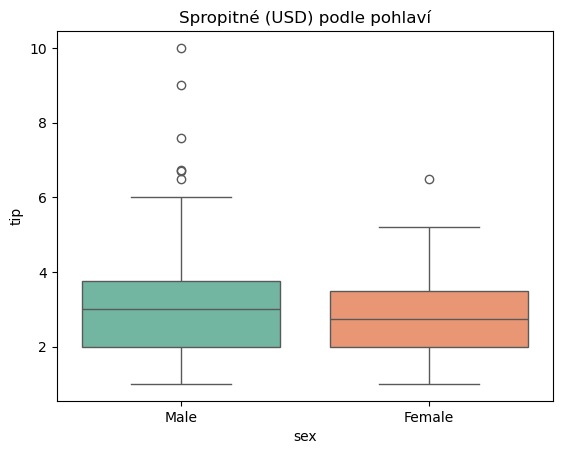

C:\Users\josef\AppData\Local\Temp\ipykernel_61236\4095471903.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tips, x="sex", y="tip_pct", palette="Set2")


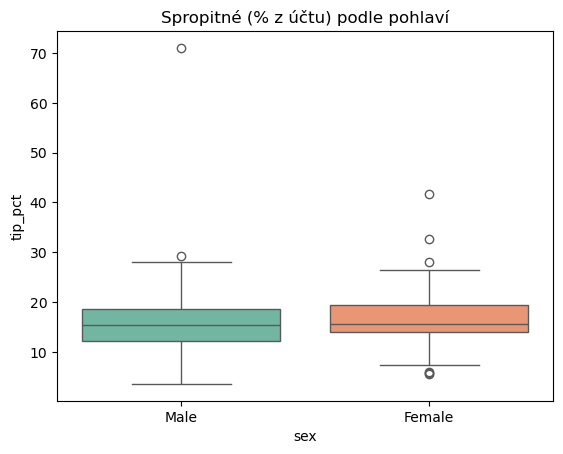

In [156]:
# nový sloupec: procento spropitného
df_tips["tip_pct"] = df_tips["tip"] / df_tips["total_bill"] * 100

# 1. Absolutní spropitné
sns.boxplot(data=df_tips, x="sex", y="tip", palette="Set2")
plt.title("Spropitné (USD) podle pohlaví")
plt.show()

# 2. Relativní spropitné
sns.boxplot(data=df_tips, x="sex", y="tip_pct", palette="Set2")
plt.title("Spropitné (% z účtu) podle pohlaví")
plt.show()

In [ ]:
# 6. Mají kuřáci tendenci nechávat jiné spropitné než nekuřáci?  

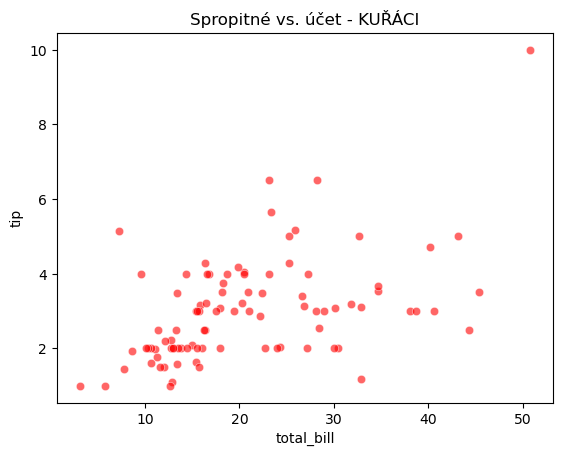

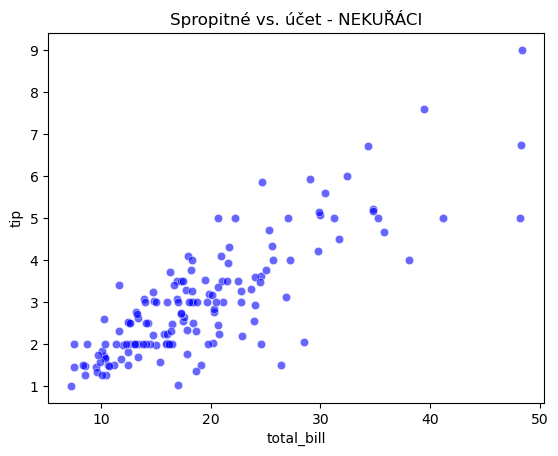

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")

# Scatter plot pro KUŘÁKY
sns.scatterplot(
    data=df_tips[df_tips["smoker"] == "Yes"],
    x="total_bill", y="tip", color="red", alpha=0.6
)
plt.title("Spropitné vs. účet - KUŘÁCI")
plt.show()

# Scatter plot pro NEKUŘÁKY
sns.scatterplot(
    data=df_tips[df_tips["smoker"] == "No"],
    x="total_bill", y="tip", color="blue", alpha=0.6
)
plt.title("Spropitné vs. účet - NEKUŘÁCI")
plt.show()


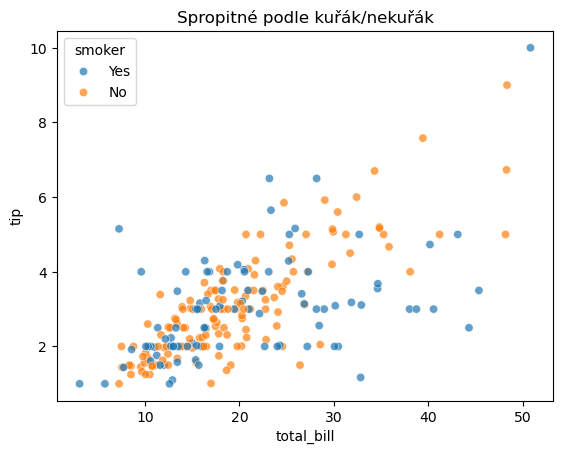

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")
df_tips["tip_pct"] = df_tips["tip"] / df_tips["total_bill"] * 100

sns.scatterplot(data=df_tips, x="total_bill", y="tip", hue="smoker", alpha=0.7)
plt.title("Spropitné podle kuřák/nekuřák")
plt.show()

In [163]:
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# 7. Jak se liší účty a spropitné mezi obědem (`Lunch`) a večeří (`Dinner`)?

# přidání sloupce se spropitným v %
df_tips["tip_pct"] = df_tips["tip"] / df_tips["total_bill"] * 100

# agregace pro Lunch a Dinner
summary = df_tips.groupby("time").agg({
    "total_bill": ["mean", "median"],
    "tip": ["mean", "median"],
    "tip_pct": ["mean", "median"]
}).round(2)

print(summary)

       total_bill          tip        tip_pct       
             mean median  mean median    mean median
time                                                
Lunch       17.17  15.96  2.73   2.25   16.41  15.41
Dinner      20.80  18.39  3.10   3.00   15.95  15.54


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\771330027.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_tips.groupby("time").agg({


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\4192172311.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_tips.groupby("time").agg({


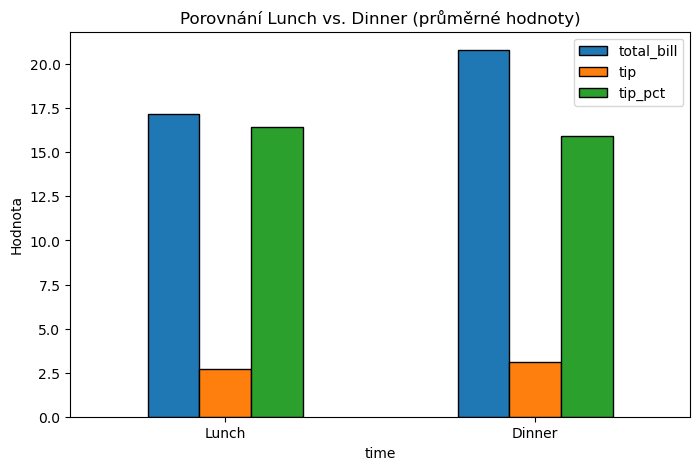

In [165]:
df_tips = sns.load_dataset("tips")
df_tips["tip_pct"] = df_tips["tip"] / df_tips["total_bill"] * 100

# průměry pro Lunch vs Dinner
summary = df_tips.groupby("time").agg({
    "total_bill": "mean",
    "tip": "mean",
    "tip_pct": "mean"
}).round(2)

# bar plot
summary.plot(kind="bar", figsize=(8,5), edgecolor="black")
plt.title("Porovnání Lunch vs. Dinner (průměrné hodnoty)")
plt.ylabel("Hodnota")
plt.xticks(rotation=0)
plt.show()

C:\Users\josef\AppData\Local\Temp\ipykernel_61236\3002246352.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tips, x="time", y="total_bill", palette="Set2", ax=axes[0])
C:\Users\josef\AppData\Local\Temp\ipykernel_61236\3002246352.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tips, x="time", y="tip", palette="Set2", ax=axes[1])
C:\Users\josef\AppData\Local\Temp\ipykernel_61236\3002246352.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tips, x="time", y="tip_pct", palette="Set2", ax=axes[2])


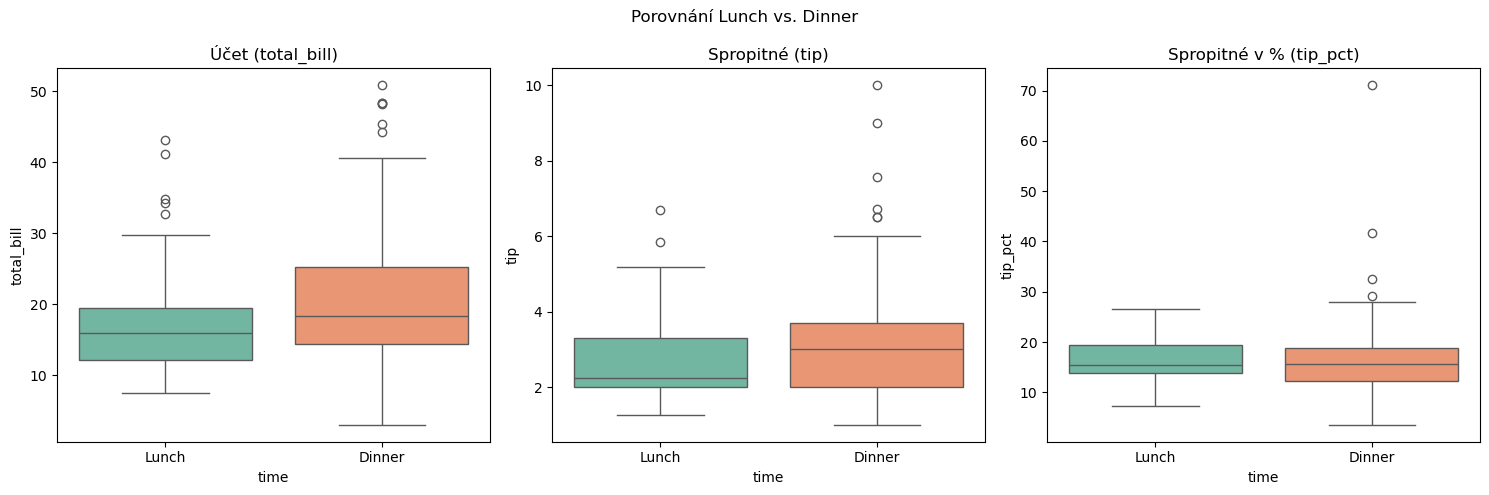

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")
df_tips["tip_pct"] = df_tips["tip"] / df_tips["total_bill"] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Účty
sns.boxplot(data=df_tips, x="time", y="total_bill", palette="Set2", ax=axes[0])
axes[0].set_title("Účet (total_bill)")

# 2. Spropitné
sns.boxplot(data=df_tips, x="time", y="tip", palette="Set2", ax=axes[1])
axes[1].set_title("Spropitné (tip)")

# 3. Spropitné v % účtu
sns.boxplot(data=df_tips, x="time", y="tip_pct", palette="Set2", ax=axes[2])
axes[2].set_title("Spropitné v % (tip_pct)")

plt.suptitle("Porovnání Lunch vs. Dinner")
plt.tight_layout()
plt.show()


day
Sun     21.410000
Sat     20.441379
Thur    17.682742
Fri     17.151579
Name: total_bill, dtype: float64

Nejvyšší průměrný účet má den: Sun ( 21.41 USD )


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\105422184.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df_tips.groupby("day")["total_bill"].mean().sort_values(ascending=False)


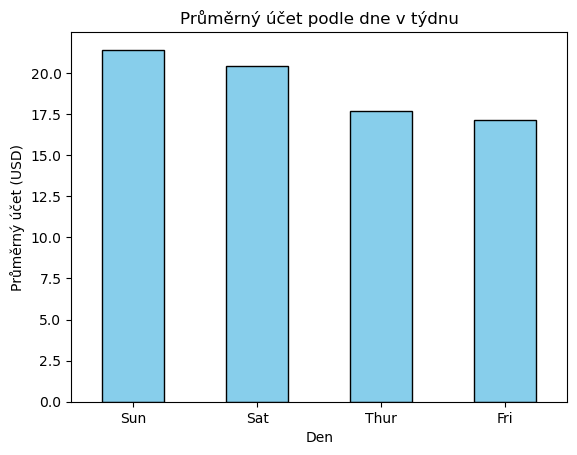

In [ ]:
# 8) Který den v týdnu má nejvyšší průměrný účet?

import seaborn as sns

df_tips = sns.load_dataset("tips")

avg_by_day = df_tips.groupby("day")["total_bill"].mean().sort_values(ascending=False)

print(avg_by_day)
print("\nNejvyšší průměrný účet má den:", avg_by_day.index[0], "(", round(avg_by_day.iloc[0], 2), "USD )")

avg_by_day.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Průměrný účet podle dne v týdnu")
plt.xlabel("Den")
plt.ylabel("Průměrný účet (USD)")
plt.xticks(rotation=0)
plt.show()


In [170]:
# 10. Jaký je průměrný účet a spropitné pro kuřáky vs. nekuřáky rozdělené podle pohlaví?

# průměrné hodnoty podle smoker + sex

summary = df_tips.groupby(["smoker", "sex"]).agg({
    "total_bill": "mean",
    "tip": "mean"
}).round(2)

print(summary)


               total_bill   tip
smoker sex                     
Yes    Male         22.28  3.05
       Female       17.98  2.93
No     Male         19.79  3.11
       Female       18.11  2.77


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\2295990984.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_tips.groupby(["smoker", "sex"]).agg({


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\4172825953.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_tips, x="sex", y="total_bill", hue="smoker", ci=None, palette="Set2", ax=axes[0])
C:\Users\josef\AppData\Local\Temp\ipykernel_61236\4172825953.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_tips, x="sex", y="tip", hue="smoker", ci=None, palette="Set2", ax=axes[1])


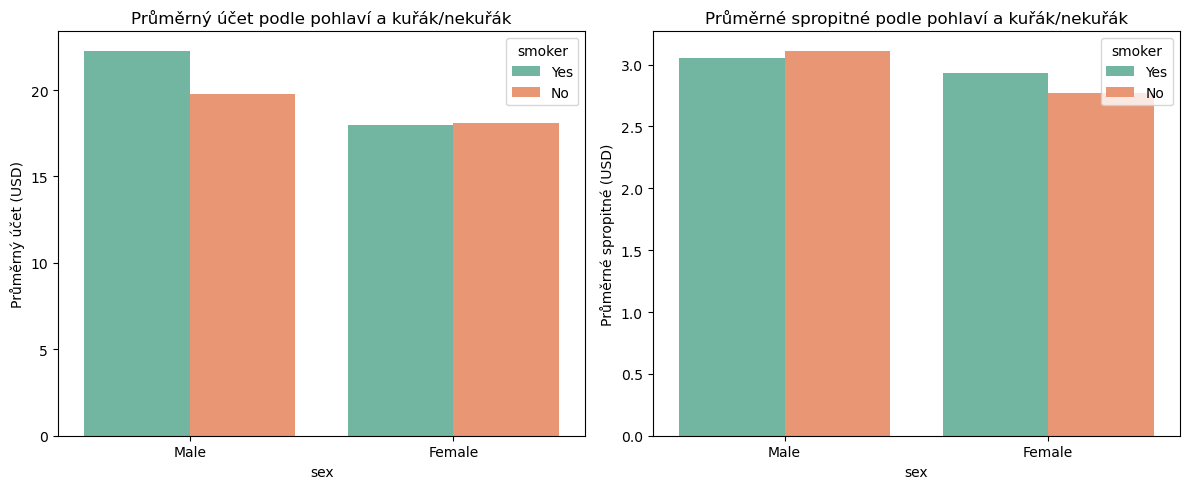

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")

# Obrázek s 2 grafy vedle sebe
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Průměrný účet
sns.barplot(data=df_tips, x="sex", y="total_bill", hue="smoker", ci=None, palette="Set2", ax=axes[0])
axes[0].set_title("Průměrný účet podle pohlaví a kuřák/nekuřák")
axes[0].set_ylabel("Průměrný účet (USD)")

# 2. Průměrné spropitné
sns.barplot(data=df_tips, x="sex", y="tip", hue="smoker", ci=None, palette="Set2", ax=axes[1])
axes[1].set_title("Průměrné spropitné podle pohlaví a kuřák/nekuřák")
axes[1].set_ylabel("Průměrné spropitné (USD)")

plt.tight_layout()
plt.show()


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\2853375490.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_tips.pivot_table(values="tip", index="sex", columns="smoker", aggfunc="mean")


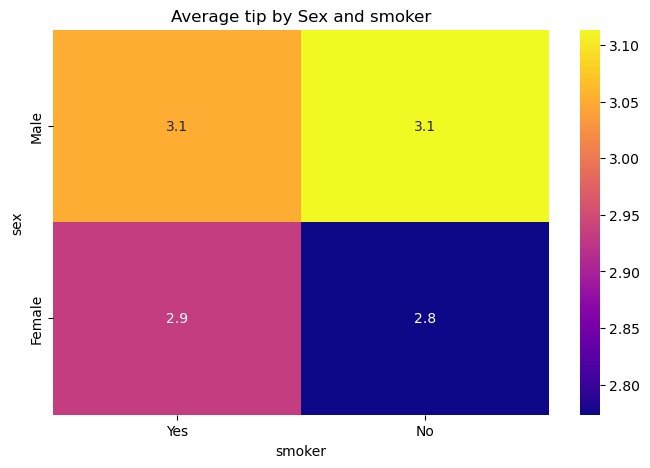

In [172]:
# 10) Jaký je průměrný účet a spropitné pro kuřáky vs. nekuřáky rozdělené podle pohlaví?

pivot = df_tips.pivot_table(values="tip", index="sex", columns="smoker", aggfunc="mean")

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot= True, cmap = "plasma",fmt=".1f")
plt.title("Average tip by Sex and smoker")
plt.show()

## 3. Vztahy mezi veličinami

11. Existuje korelace mezi výší účtu (`total_bill`) a výší spropitného (`tip`)?  
12. Zvyšuje se spropitné (v dolarech i %) s počtem osob u stolu (`size`)?  
13. Je procento spropitného vyšší u menších nebo větších účtů?  
14. Existuje vztah mezi velikostí skupiny (`size`) a procentem spropitného?  
15. Je korelace mezi účtem a spropitným silnější pro oběd nebo večeři?  
16. Jak se mění variabilita spropitného s počtem osob u stolu?  

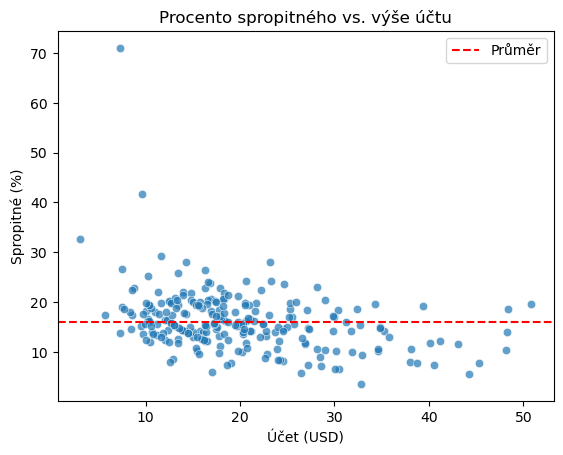

In [173]:
# 13) Je procento spropitného vyšší u menších nebo větších účtů?

import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")
df_tips["tip_pct"] = df_tips["tip"] / df_tips["total_bill"] * 100

sns.scatterplot(data=df_tips, x="total_bill", y="tip_pct", alpha=0.7)
plt.axhline(df_tips["tip_pct"].mean(), color="red", linestyle="--", label="Průměr")
plt.xlabel("Účet (USD)")
plt.ylabel("Spropitné (%)")
plt.title("Procento spropitného vs. výše účtu")
plt.legend()
plt.show()


In [ ]:
# 14) Existuje vztah mezi velikostí skupiny (size) a procentem spropitného?

C:\Users\josef\AppData\Local\Temp\ipykernel_61236\2841657317.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tips, x="size", y="tip_pct", palette="Set2")


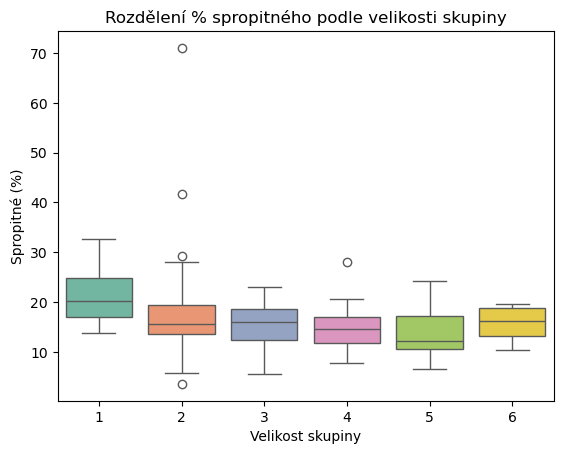

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")
df_tips["tip_pct"] = df_tips["tip"] / df_tips["total_bill"] * 100

sns.boxplot(data=df_tips, x="size", y="tip_pct", palette="Set2")
plt.title("Rozdělení % spropitného podle velikosti skupiny")
plt.xlabel("Velikost skupiny")
plt.ylabel("Spropitné (%)")
plt.show()

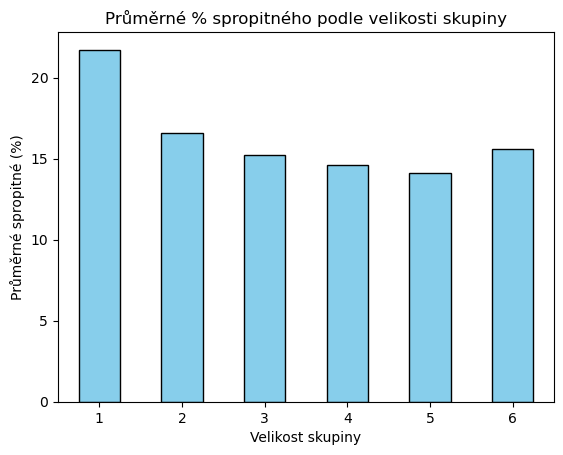

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")
df_tips["tip_pct"] = df_tips["tip"] / df_tips["total_bill"] * 100

# průměrné % spropitného podle velikosti skupiny
avg_tip_pct = df_tips.groupby("size")["tip_pct"].mean()

avg_tip_pct.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Průměrné % spropitného podle velikosti skupiny")
plt.xlabel("Velikost skupiny")
plt.ylabel("Průměrné spropitné (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:

# 15) Je korelace mezi účtem a spropitným silnější pro oběd nebo večeři?

import seaborn as sns

df_tips = sns.load_dataset("tips")

# korelace pro Lunch
corr_lunch = df_tips[df_tips["time"]=="Lunch"][["total_bill", "tip"]].corr().iloc[0,1]

# korelace pro Dinner
corr_dinner = df_tips[df_tips["time"]=="Dinner"][["total_bill", "tip"]].corr().iloc[0,1]

print("Korelace total_bill vs. tip (Lunch):", round(corr_lunch, 3))
print("Korelace total_bill vs. tip (Dinner):", round(corr_dinner, 3))


Korelace total_bill vs. tip (Lunch): 0.805
Korelace total_bill vs. tip (Dinner): 0.633


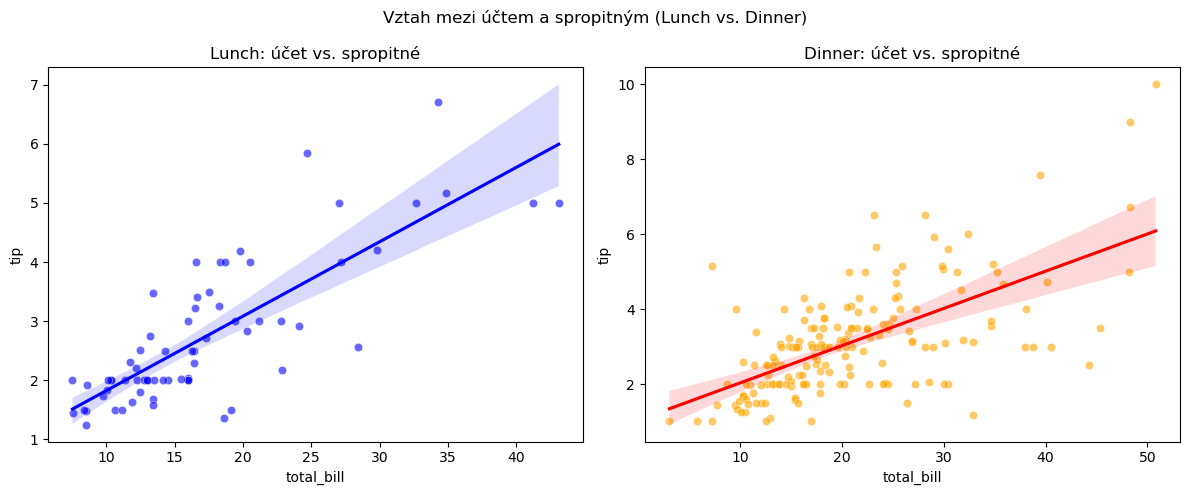

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Scatter pro Lunch
sns.scatterplot(data=df_tips[df_tips["time"]=="Lunch"],
                x="total_bill", y="tip", color="blue", alpha=0.6, ax=axes[0])
sns.regplot(data=df_tips[df_tips["time"]=="Lunch"],
            x="total_bill", y="tip", scatter=False, color="blue", ax=axes[0])
axes[0].set_title("Lunch: účet vs. spropitné")

# Scatter pro Dinner
sns.scatterplot(data=df_tips[df_tips["time"]=="Dinner"],
                x="total_bill", y="tip", color="orange", alpha=0.6, ax=axes[1])
sns.regplot(data=df_tips[df_tips["time"]=="Dinner"],
            x="total_bill", y="tip", scatter=False, color="red", ax=axes[1])
axes[1].set_title("Dinner: účet vs. spropitné")

plt.suptitle("Vztah mezi účtem a spropitným (Lunch vs. Dinner)")
plt.tight_layout()
plt.show()


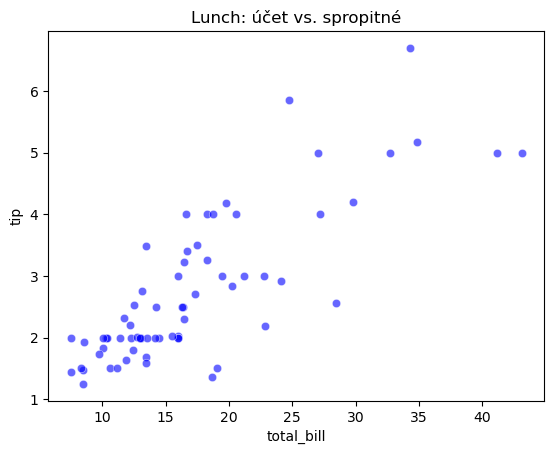

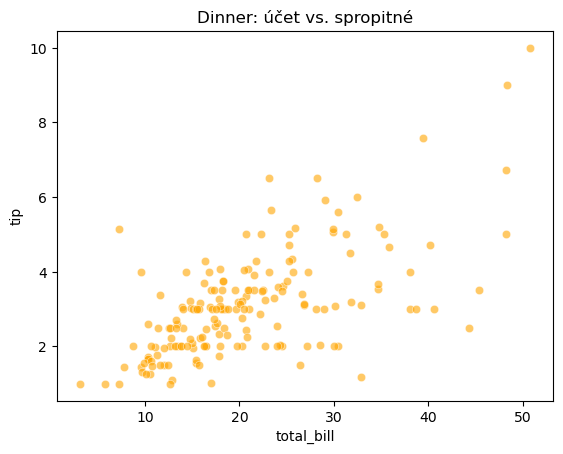

In [ ]:

# 15) Je korelace mezi účtem a spropitným silnější pro oběd nebo večeři?

import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")

# Scatter plot pro Lunch
sns.scatterplot(
    data=df_tips[df_tips["time"] == "Lunch"],
    x="total_bill", y="tip",
    color="blue", alpha=0.6
)
plt.title("Lunch: účet vs. spropitné")
plt.show()

# Scatter plot pro Dinner
sns.scatterplot(
    data=df_tips[df_tips["time"] == "Dinner"],
    x="total_bill", y="tip",
    color="orange", alpha=0.6
)
plt.title("Dinner: účet vs. spropitné")
plt.show()


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\2214507012.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tips, x="size", y="tip", palette="Set2")


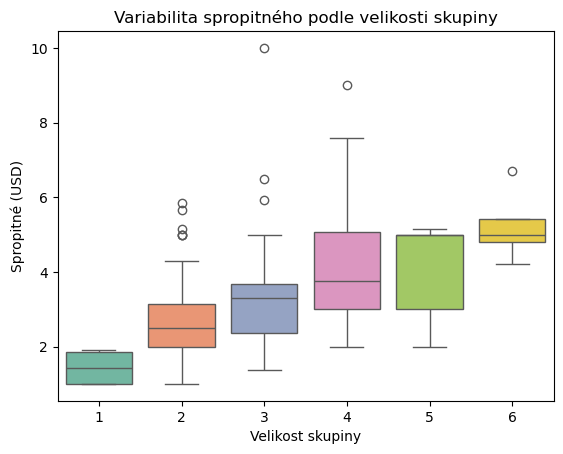

In [ ]:
# 16) Jak se mění variabilita spropitného s počtem osob u stolu

import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")

sns.boxplot(data=df_tips, x="size", y="tip", palette="Set2")
plt.title("Variabilita spropitného podle velikosti skupiny")
plt.xlabel("Velikost skupiny")
plt.ylabel("Spropitné (USD)")
plt.show()

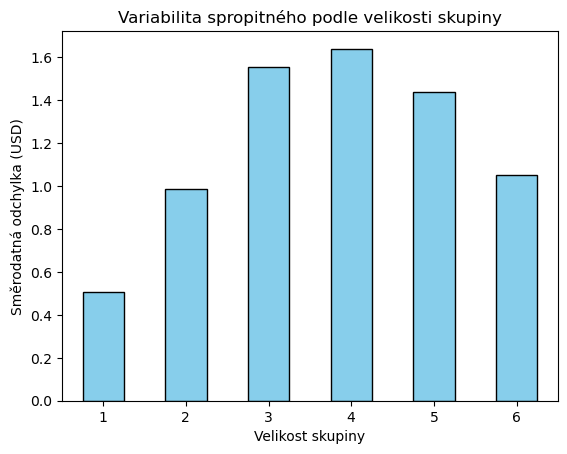

In [ ]:
# 16) Jak se mění variabilita spropitného s počtem osob u stolu

import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")

# směrodatná odchylka spropitného podle velikosti skupiny
tip_std = df_tips.groupby("size")["tip"].std()

# bar plot
tip_std.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Variabilita spropitného podle velikosti skupiny")
plt.xlabel("Velikost skupiny")
plt.ylabel("Směrodatná odchylka (USD)")
plt.xticks(rotation=0)
plt.show()


## 4. Časové a denní trendy
17. Existuje rozdíl v spropitném mezi obědem a večeří pro každý den zvlášť?  
18. Který den v týdnu má nejvyšší průměrné procento spropitného (tip / total_bill)?  
19. Dá se odhadnout, zda lidé chodí častěji v určité dny nebo časy?  

C:\Users\josef\AppData\Local\Temp\ipykernel_61236\886905688.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_tips.pivot_table(


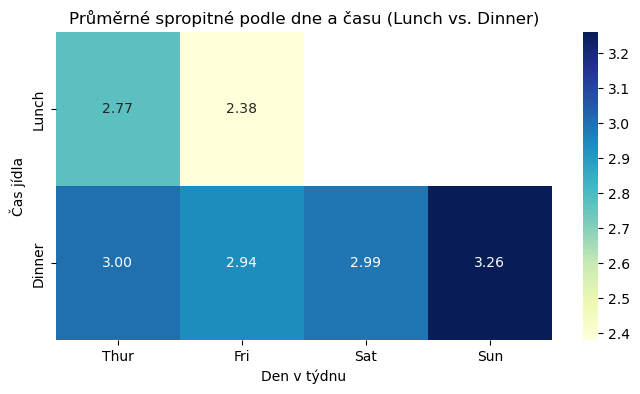

In [ ]:
# 17) Existuje rozdíl v spropitném mezi obědem a večeří pro každý den zvlášť?  

import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")

# pivot: průměrné spropitné pro kombinaci den × čas
pivot = df_tips.pivot_table(
    values="tip",
    index="time",      # Lunch / Dinner
    columns="day",     # den v týdnu
    aggfunc="mean"
).round(2)

# heatmapa
plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Průměrné spropitné podle dne a času (Lunch vs. Dinner)")
plt.ylabel("Čas jídla")
plt.xlabel("Den v týdnu")
plt.show()


C:\Users\josef\AppData\Local\Temp\ipykernel_61236\2458847805.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_tips.pivot_table(values="tip", index="time", columns="day", aggfunc="mean").round(2)


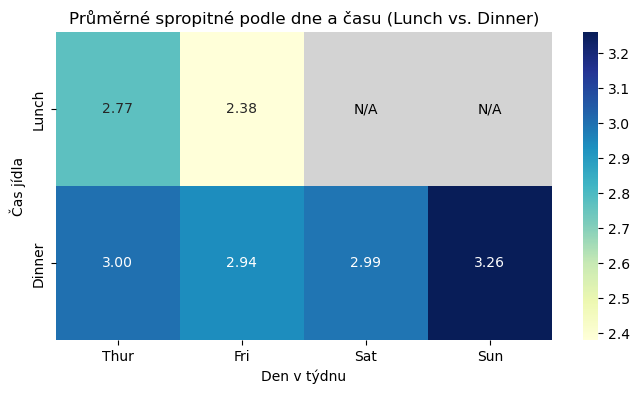

In [ ]:
# 17) Existuje rozdíl v spropitném mezi obědem a večeří pro každý den zvlášť?

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_tips = sns.load_dataset("tips")

pivot = df_tips.pivot_table(values="tip", index="time", columns="day", aggfunc="mean").round(2)
mask = pivot.isna()

# šedá pro chybějící hodnoty
cmap = sns.color_palette("YlGnBu", as_cmap=True)
cmap.set_bad("lightgray")

plt.figure(figsize=(8,4))
ax = sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, mask=mask)

# dopiš "N/A" do prázdných (maskovaných) buněk
for r, c in zip(*np.where(mask)):
    ax.text(c + 0.5, r + 0.5, "N/A", ha="center", va="center", fontsize=10, color="black")

plt.title("Průměrné spropitné podle dne a času (Lunch vs. Dinner)")
plt.ylabel("Čas jídla")
plt.xlabel("Den v týdnu")
plt.show()





C:\Users\josef\AppData\Local\Temp\ipykernel_61236\3765904705.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_tips.pivot_table(values="tip_pct", index="time", columns="day", aggfunc="mean").round(2)


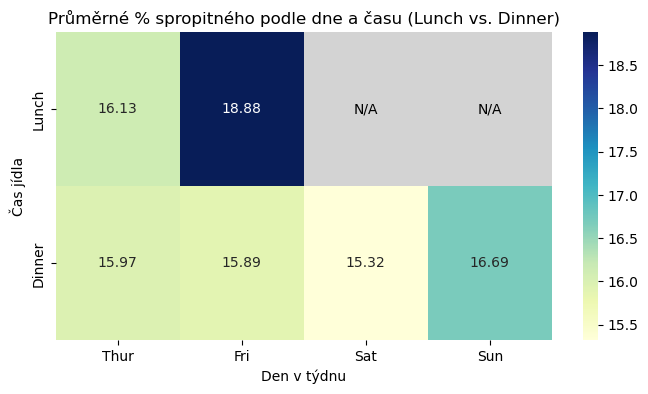

In [ ]:
# 19) Který den v týdnu má nejvyšší průměrné procento spropitného (tip / total_bill)?

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_tips = sns.load_dataset("tips")
df_tips["tip_pct"] = df_tips["tip"] / df_tips["total_bill"] * 100

# pivot tabulka: průměrné % spropitného podle dne a času
pivot = df_tips.pivot_table(values="tip_pct", index="time", columns="day", aggfunc="mean").round(2)
mask = pivot.isna()

# šedá pro chybějící hodnoty
cmap = sns.color_palette("YlGnBu", as_cmap=True)
cmap.set_bad("lightgray")

plt.figure(figsize=(8,4))
ax = sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, mask=mask)

# dopis "N/A" do prázdných buněk
for r, c in zip(*np.where(mask)):
    ax.text(c + 0.5, r + 0.5, "N/A", ha="center", va="center", fontsize=10, color="black")

plt.title("Průměrné % spropitného podle dne a času (Lunch vs. Dinner)")
plt.ylabel("Čas jídla")
plt.xlabel("Den v týdnu")
plt.show()
